In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from transformers import pipeline
import seaborn as sns

In [32]:
df = pd.read_csv('bworld_master_2021_2026.csv')
df_inf = pd.read_excel("Inflation rates from upto march.xlsx")

In [42]:
df = df[df['date'] >= '2021-01-01']

In [43]:
df['date'] = pd.to_datetime(df['date'])

df['headline_clean'] = df['headline'].str.lower()

In [44]:
def clean_finance_text(text):
    text = text.lower()

    text = re.sub(r'(?<!\d)[.,:!](?!\d) | [^\s\w.]', '', text)
    return text

df['headline_clean'] = df['headline_clean'].apply(clean_finance_text)

In [45]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split() 
    filtered_words = [w for w in words if w not in stop_words]
    return ' '.join(filtered_words)

df['headline_clean'] = df['headline_clean'].apply(remove_stopwords)

df[['headline', 'headline_clean']]

,headline,headline_clean
0,Term deposit yield ends higher as market sees ...,term deposit yield ends higher market sees bsp...
1,AIA Philippines eyes sustained profit growth a...,aia philippines eyes sustained profit growth a...
2,Peso rises on US-Iran deal hopes,peso rises us-iran deal hopes
3,PBB net income drops to P221.56M,pbb net income drops p221.56m
4,Bond yields surge on CPI data,bond yields surge cpi data
...,...,...
6550,LANDBANK’s agricultural loans hit P232 billion,landbank’s agricultural loans hit p232 billion
6551,"Rates of T-bills, bonds to move sideways as vi...",rates t-billsbonds move sideways virus fears p...
6552,China caps real estate loans to curb risks,china caps real estate loans curb risks
6553,Gov’t debt yields flat on rate cut hints,gov’t debt yields flat rate cut hints


In [46]:
finbert = pipeline('sentiment-analysis', model = 'ProsusAI/finbert')

In [51]:
def get_finbertscore(headline):
    result = finbert(headline, top_k = None)
    scores = {res['label']: res['score'] for res in result}
    return scores['positive'] - scores['negative']

df['sentiment'] = df['headline_clean'].apply(get_finbertscore)


In [48]:
df[df['sentiment'] == 0].count()

date              0
headline          0
inflation         0
headline_clean    0
sentiment         0
dtype: int64

In [57]:
df = df.set_index('date')

KeyError: "None of ['date'] are in the columns"

In [58]:
df_sent = df[['sentiment']].resample('M').mean()

In [64]:
df_sent['date'] = pd.to_datetime(df_sent['date']).dt.to_period('M').dt.to_timestamp()

In [65]:
df_inf['month'] = pd.to_datetime(df_inf['month']).dt.to_period('M').dt.to_timestamp()

In [67]:
df_sent['inflation'] = df_inf['inflation']

In [112]:
df_sent['inflation'].corr(df_sent['sentiment'].shift(-1))

0.216379513676081

In [90]:
df_sent = df_sent.set_index('date')

<function matplotlib.pyplot.show(close=None, block=None)>

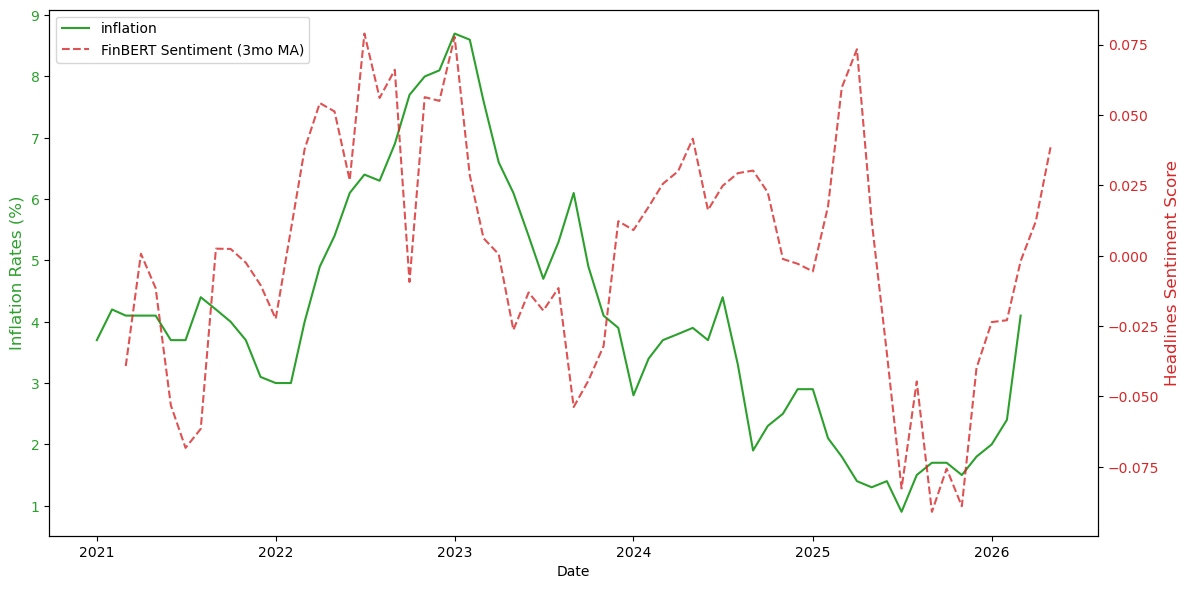

In [124]:
fig, ax1 = plt.subplots(figsize = (12,6))

ax1.plot(df_sent.index, df_sent['inflation'], color = 'tab:green', label = 'inflation')
ax1.set_xlabel('Date')
ax1.set_ylabel('Inflation Rates (%)', color = 'tab:green', fontsize = 12)
ax1.tick_params(axis = 'y', labelcolor = 'tab:green')

ax2 = ax1.twinx()

ax2.plot(df_sent.index, df_sent['sentiment'].rolling(window = 3).mean(), color = 'tab:red', label = 'FinBERT Sentiment (3mo MA)', linestyle = '--', alpha = 0.8)
ax2.set_ylabel('Headlines Sentiment Score', color = 'tab:red', fontsize = 12)
ax2.tick_params(axis = 'y', labelcolor = 'tab:red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines + lines2, labels + labels2, loc = 'upper left')
fig.tight_layout()
plt.show

In [98]:
momentum_corr = df_sent['inflation'].diff().corr(df_sent['sentiment'].shift(1).diff())
print(f"Momentum Correlation: {momentum_corr}")

Momentum Correlation: -0.06888583125477533


In [102]:
print(df_sent['inflation'].corr(df_sent['sentiment'].rolling(3).mean()))

0.41298225663635624


In [117]:
df_sent.reset_index().to_csv('finBERT Sentiment-Inflation.csv', index = False)

In [120]:
df_sent

,sentiment,inflation
date,,
2021-01-01,-0.096034,3.7
2021-02-01,0.019575,4.2
2021-03-01,-0.041243,4.1
2021-04-01,0.023667,4.1
2021-05-01,-0.017046,4.1
...,...,...
2026-01-01,-0.028967,2.0
2026-02-01,-0.000079,2.4
2026-03-01,0.023276,4.1
